In [1]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Mounted at /content/drive
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


# Install

In [2]:
!pip install neuralforecast[patchtst] scikit-learn pandas numpy
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import torch
print(torch.cuda.is_available())

from neuralforecast.models import PatchTST
from neuralforecast import NeuralForecast

False


# Preprocessing

In [4]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

class WalmartPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, stores, features):
        self.stores = stores
        self.features = features
        self.label_encoder = None

    def fit(self, X, y=None):
        all_data = X.merge(self.stores, how='left', on='Store')
        if 'Type' in all_data.columns:
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(all_data['Type'].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        X = X.merge(self.stores, how='left', on='Store')
        X = X.merge(self.features, how='left', on=['Store', 'Date', 'IsHoliday'])

        X['Date'] = pd.to_datetime(X['Date'])

        if self.label_encoder is not None and 'Type' in X.columns:
            X['Type'] = self.label_encoder.transform(X['Type'].astype(str))

        X.fillna(0, inplace=True)

        X.sort_values(['Store', 'Dept', 'Date'], inplace=True)
        X.reset_index(drop=True, inplace=True)

        return X

df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

preprocessor = WalmartPreprocessor(stores=stores, features=features)
preprocessor.fit(df)
df = preprocessor.transform(df)

In [6]:
df['Weekly_Sales'] = df['Weekly_Sales'].astype(float)

val_date = pd.to_datetime('2011-10-01')

train_df = df[df['Date'] < val_date]
valid_df = df[df['Date'] >= val_date]

X_train = train_df.drop(columns=['Weekly_Sales'])
y_train = train_df['Weekly_Sales']

X_valid = valid_df.drop(columns=['Weekly_Sales'])
y_valid = valid_df['Weekly_Sales']

In [7]:
from neuralforecast.models import PatchTST
from neuralforecast import NeuralForecast

class NeuralForecastWrapper:
    def __init__(self, model, freq='W-FRI', group_cols=['Store', 'Dept'], date_col='Date'):
        self.model = model
        self.freq = freq
        self.group_cols = group_cols
        self.date_col = date_col
        self.nf = None
        self.fitted = False

    def _prepare_df(self, X, y=None):
        df = X.copy()
        df['ds'] = df[self.date_col]
        df['unique_id'] = df[self.group_cols].astype(str).agg('-'.join, axis=1)
        if y is not None:
            df['y'] = y.values
            return df[['unique_id', 'ds', 'y']]
        return df[['unique_id', 'ds']]

    def fit(self, X, y):
        df = self._prepare_df(X, y)
        self.nf = NeuralForecast(models=[self.model], freq=self.freq)
        self.nf.fit(df)
        self.fitted = True

    def predict(self, X_test):
        if not self.fitted:
            raise RuntimeError("Call fit() before predict().")

        test_df = self._prepare_df(X_test)
        test_df['ds'] = pd.to_datetime(test_df['ds'])

        forecast = self.nf.predict()
        forecast['ds'] = pd.to_datetime(forecast['ds'])

        forecast = forecast.rename(columns={self.model.__class__.__name__: 'y_pred'})
        result = test_df.merge(forecast, on=['unique_id', 'ds'], how='left')

        return pd.Series(result['y_pred'].fillna(0).values, index=X_test.index)

In [12]:
from neuralforecast.models import PatchTST
from sklearn.pipeline import Pipeline

model = PatchTST(
    h=60,
    input_size=70,
    patch_len=16,
    stride=4,
    n_heads=4,
    dropout=0.1,
    max_steps=100,
    learning_rate=5e-4,
    enable_progress_bar=True
)
patch_model = NeuralForecastWrapper(model=model)

patch_model.fit(X_train,y_train)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 516 K  | train
-----------------------------------------------------------
516 K     Trainable params
3         Non-trainable params
516 K     Total params
2.067     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


In [13]:
y_pred = patch_model.predict(X_valid)

import numpy as np
from sklearn.metrics import mean_squared_error

def compute_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

wmae = compute_wmae(y_valid.values, y_pred.values, X_valid['IsHoliday'].values)

rmse = np.sqrt(mean_squared_error(y_valid.values, y_pred.values))

print(f"WMAE: {wmae:.2f}")
print(f"RMSE: {rmse:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 3000.07
RMSE: 6493.12


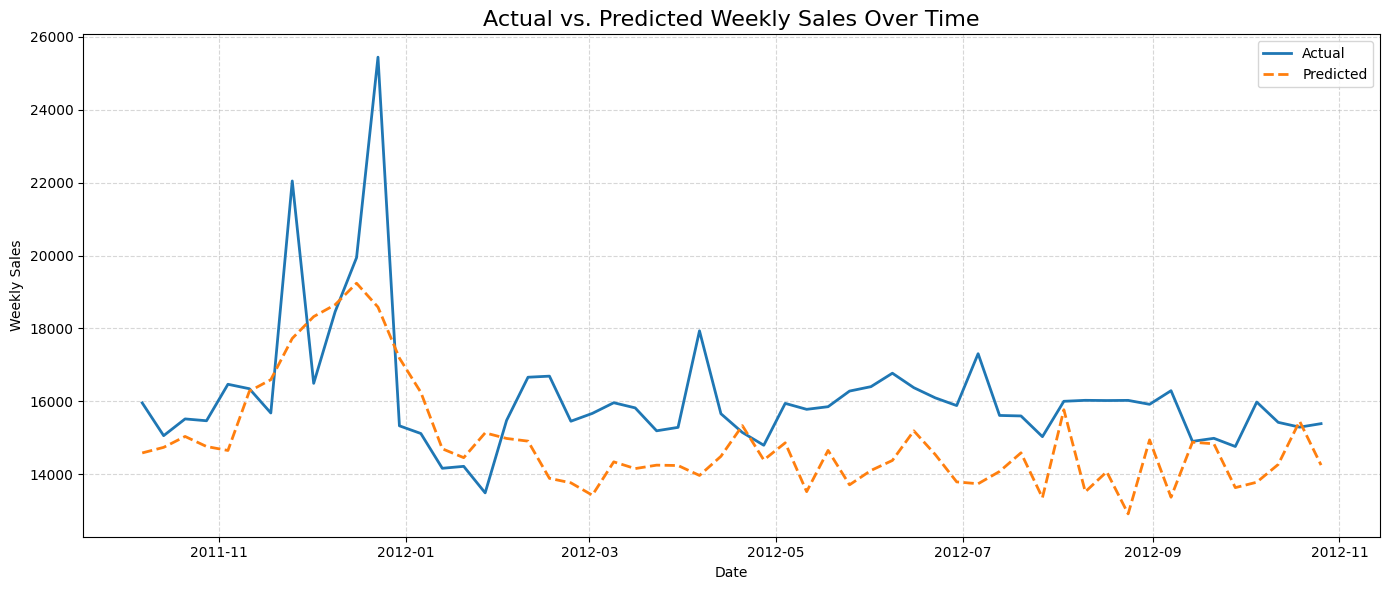

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = pd.DataFrame({
    'Date': pd.to_datetime(X_valid['Date']),
    'Actual': y_valid.values,
    'Predicted': y_pred.values
})

df_plot_grouped = df_plot.groupby('Date')[['Actual', 'Predicted']].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_plot_grouped, x='Date', y='Actual', label='Actual', linewidth=2)
sns.lineplot(data=df_plot_grouped, x='Date', y='Predicted', label='Predicted', linewidth=2, linestyle='--')

plt.title('Actual vs. Predicted Weekly Sales Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# hyper parameter tuning

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 52


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 485 K  | train
-----------------------------------------------------------
485 K     Trainable params
3         Non-trainable params
485 K     Total params
1.942     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2723.12
RMSE: 6190.17


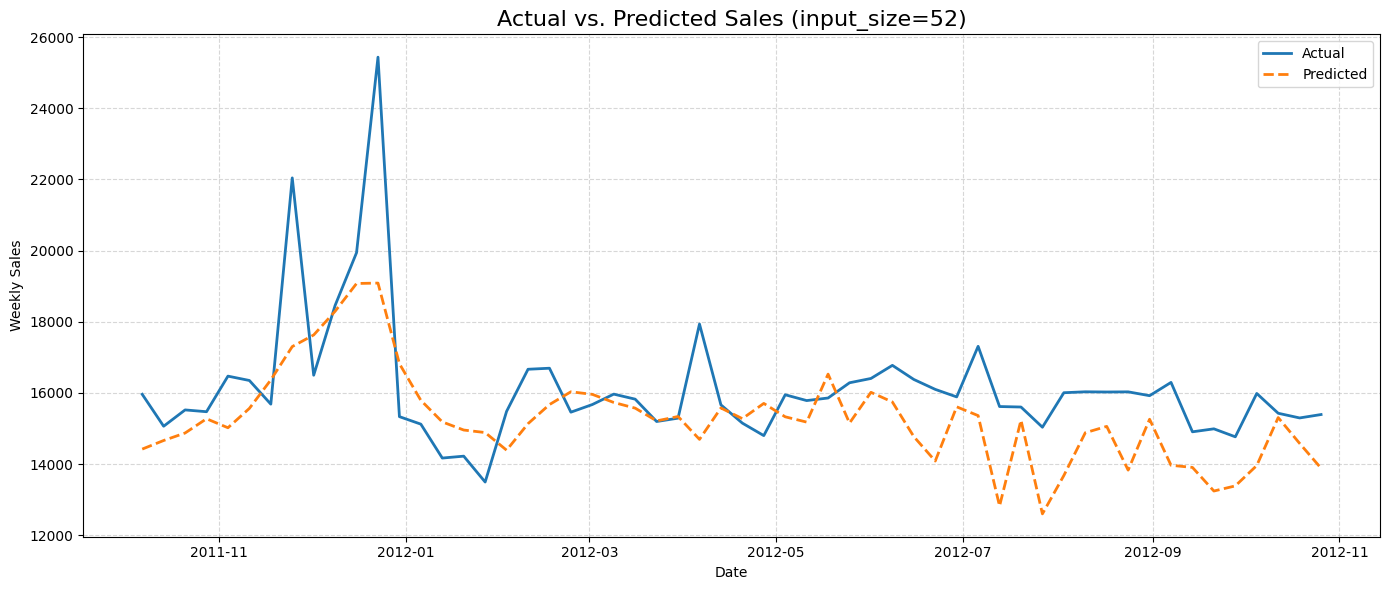

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 60


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 501 K  | train
-----------------------------------------------------------
501 K     Trainable params
3         Non-trainable params
501 K     Total params
2.005     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2778.77
RMSE: 6207.07


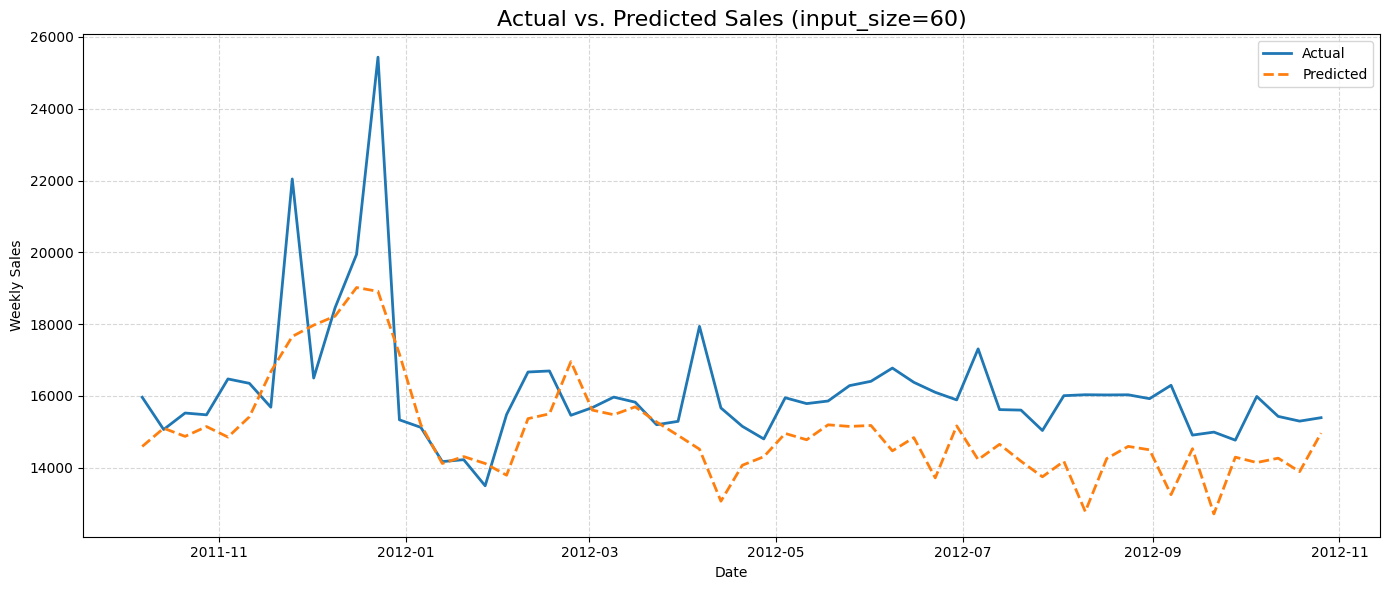

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 70


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 516 K  | train
-----------------------------------------------------------
516 K     Trainable params
3         Non-trainable params
516 K     Total params
2.067     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 3000.07
RMSE: 6493.12


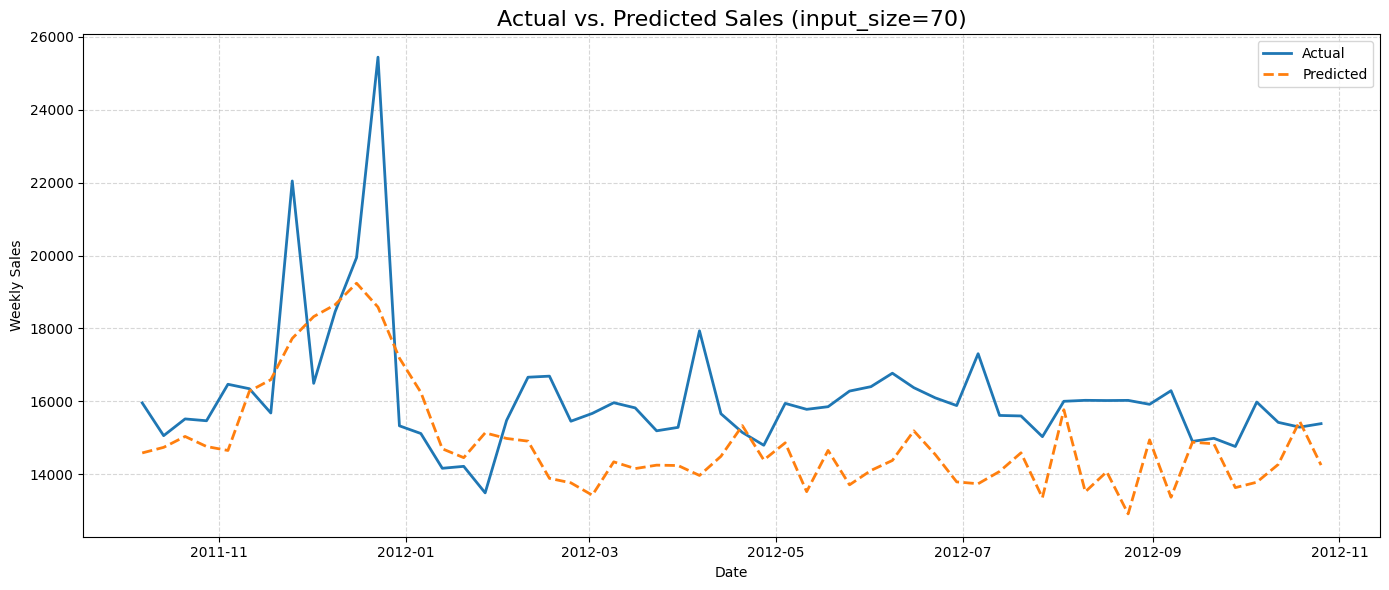


Best input_size: None with WMAE: 2723.12


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def compute_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

best_wmae = float('inf')
best_param = None

for param in [52, 60, 70]:
    print(f"\nTraining with input_size = {param}")

    model = PatchTST(
        h=60,
        input_size=param,
        patch_len=16,
        stride=4,
        n_heads=4,
        dropout=0.1,
        max_steps=100,
        learning_rate=5e-4,
        enable_progress_bar=True
    )

    patch_model = NeuralForecastWrapper(model=model)
    patch_model.fit(X_train, y_train)

    y_pred = patch_model.predict(X_valid)

    wmae = compute_wmae(y_valid.values, y_pred.values, X_valid['IsHoliday'].values)
    rmse = np.sqrt(mean_squared_error(y_valid.values, y_pred.values))

    print(f"WMAE: {wmae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    if wmae < best_wmae:
        best_wmae = wmae
        best_param = param

    df_plot = pd.DataFrame({
        'Date': pd.to_datetime(X_valid['Date']),
        'Actual': y_valid.values,
        'Predicted': y_pred.values
    })

    df_plot_grouped = df_plot.groupby('Date')[['Actual', 'Predicted']].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_plot_grouped, x='Date', y='Actual', label='Actual', linewidth=2)
    sns.lineplot(data=df_plot_grouped, x='Date', y='Predicted', label='Predicted', linewidth=2, linestyle='--')

    plt.title(f'Actual vs. Predicted Sales (input_size={param})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print(f"\nBest input_size: {best_param} with WMAE: {best_wmae:.2f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 4


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 507 K  | train
-----------------------------------------------------------
507 K     Trainable params
3         Non-trainable params
507 K     Total params
2.030     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2794.07
RMSE: 6168.02


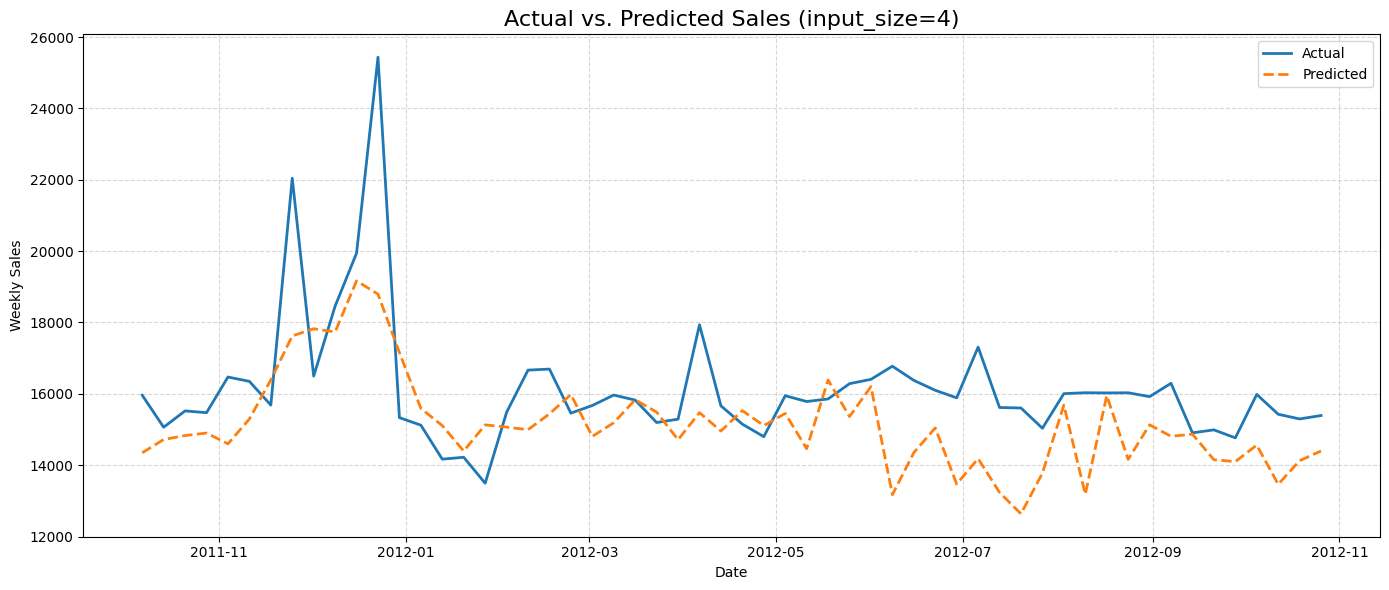

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 8


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2718.80
RMSE: 6022.13


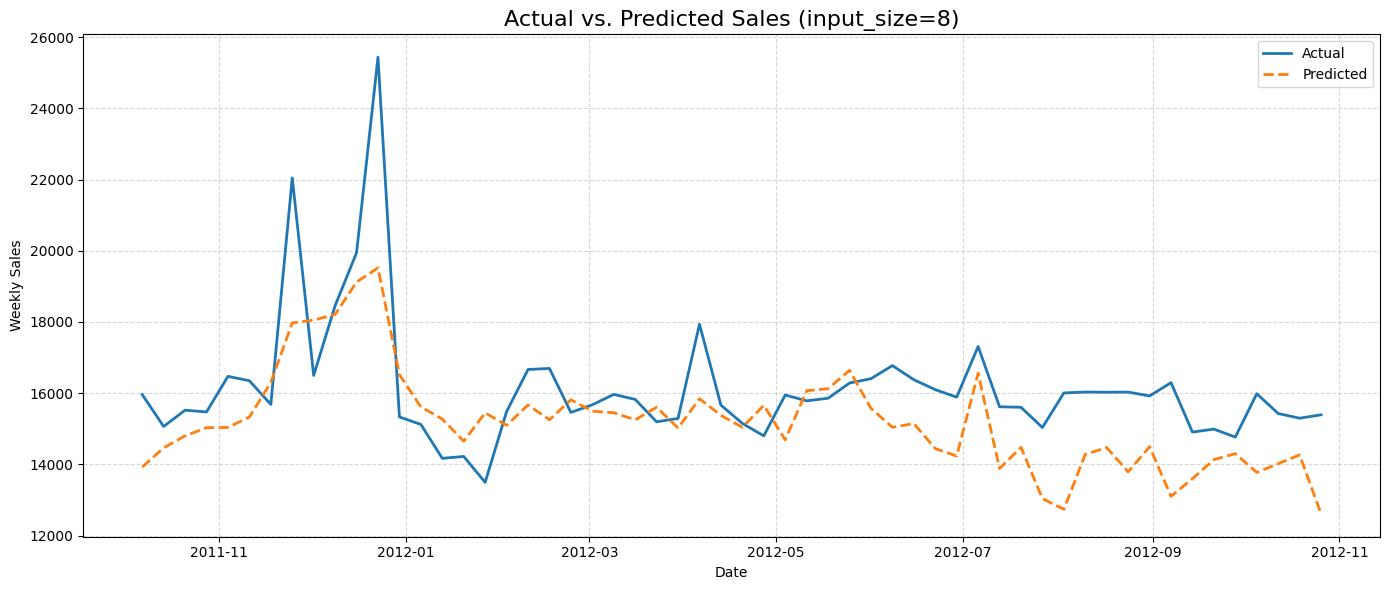

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 16


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 485 K  | train
-----------------------------------------------------------
485 K     Trainable params
3         Non-trainable params
485 K     Total params
1.942     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2723.12
RMSE: 6190.17


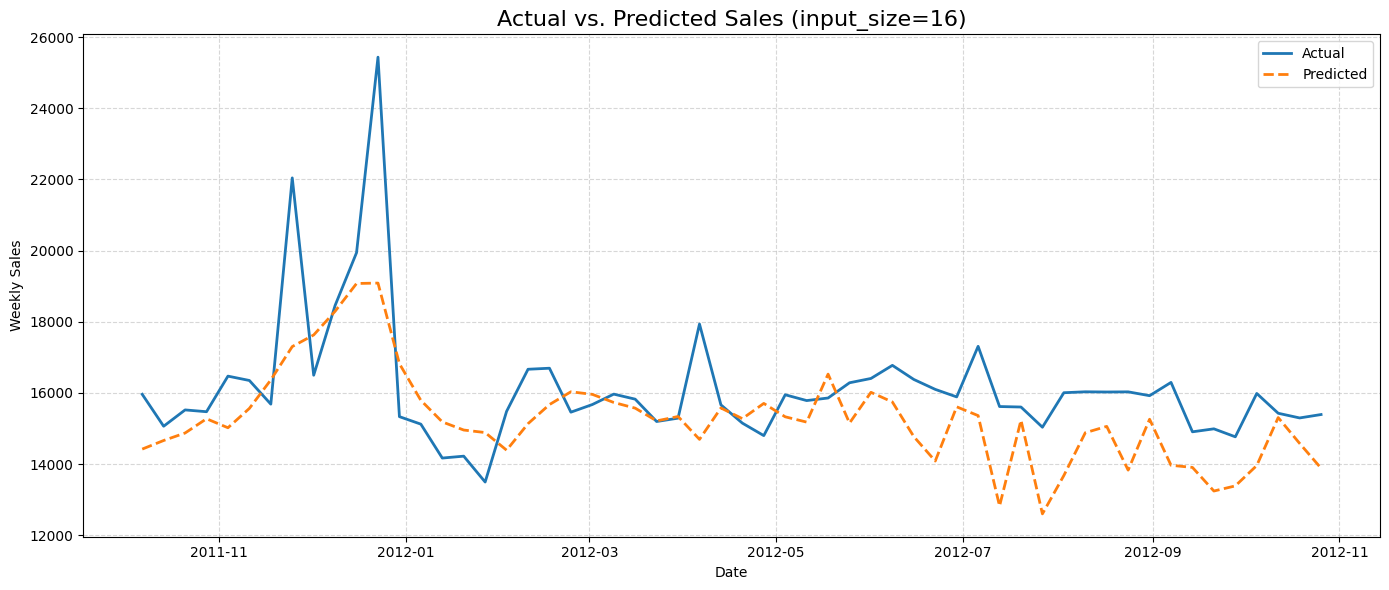

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 24


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 470 K  | train
-----------------------------------------------------------
470 K     Trainable params
3         Non-trainable params
470 K     Total params
1.884     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2757.04
RMSE: 6356.94


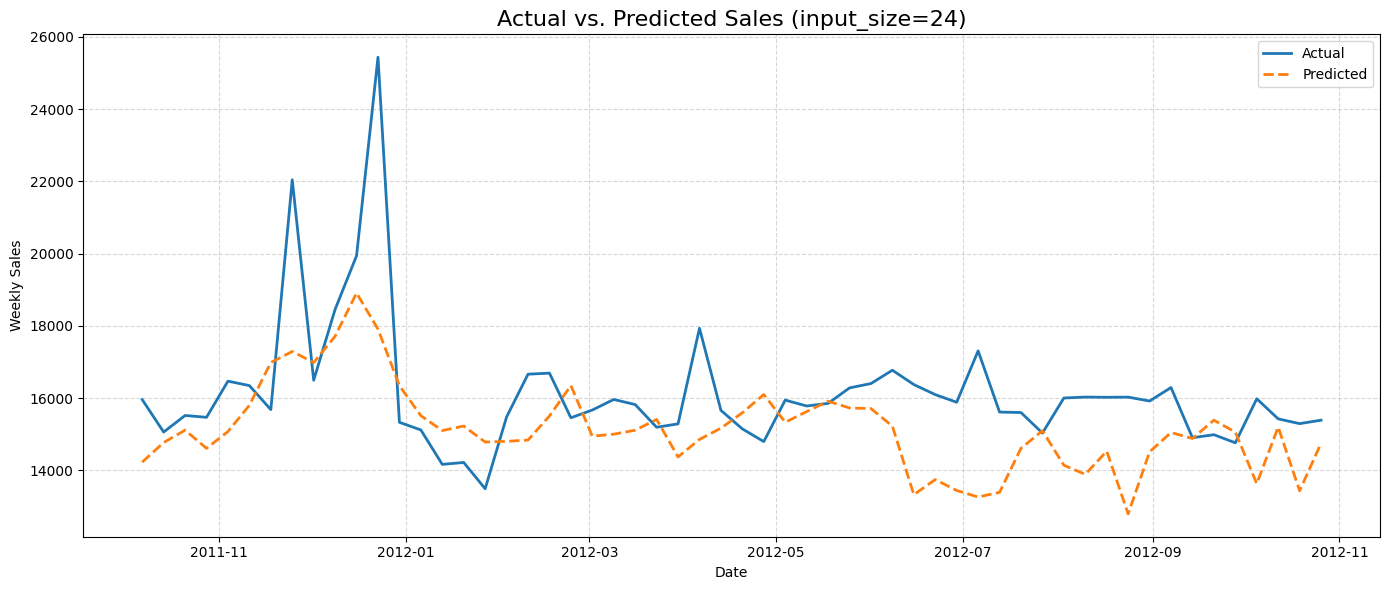


Best input_size: 8 with WMAE: 2718.80


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def compute_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

best_wmae = float('inf')
best_param = None

for param in [4, 8, 16, 24]:
    print(f"\nTraining with input_size = {param}")

    model = PatchTST(
        h=60,
        input_size=52,
        patch_len=param,
        stride=4,
        n_heads=4,
        dropout=0.1,
        max_steps=100,
        learning_rate=5e-4,
        enable_progress_bar=True
    )

    patch_model = NeuralForecastWrapper(model=model)
    patch_model.fit(X_train, y_train)

    y_pred = patch_model.predict(X_valid)

    wmae = compute_wmae(y_valid.values, y_pred.values, X_valid['IsHoliday'].values)
    rmse = np.sqrt(mean_squared_error(y_valid.values, y_pred.values))

    print(f"WMAE: {wmae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    if wmae < best_wmae:
        best_wmae = wmae
        best_param = param

    df_plot = pd.DataFrame({
        'Date': pd.to_datetime(X_valid['Date']),
        'Actual': y_valid.values,
        'Predicted': y_pred.values
    })

    df_plot_grouped = df_plot.groupby('Date')[['Actual', 'Predicted']].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_plot_grouped, x='Date', y='Actual', label='Actual', linewidth=2)
    sns.lineplot(data=df_plot_grouped, x='Date', y='Predicted', label='Predicted', linewidth=2, linestyle='--')

    plt.title(f'Actual vs. Predicted Sales (input_size={param})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print(f"\nBest input_size: {best_param} with WMAE: {best_wmae:.2f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 32


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2718.80
RMSE: 6022.13


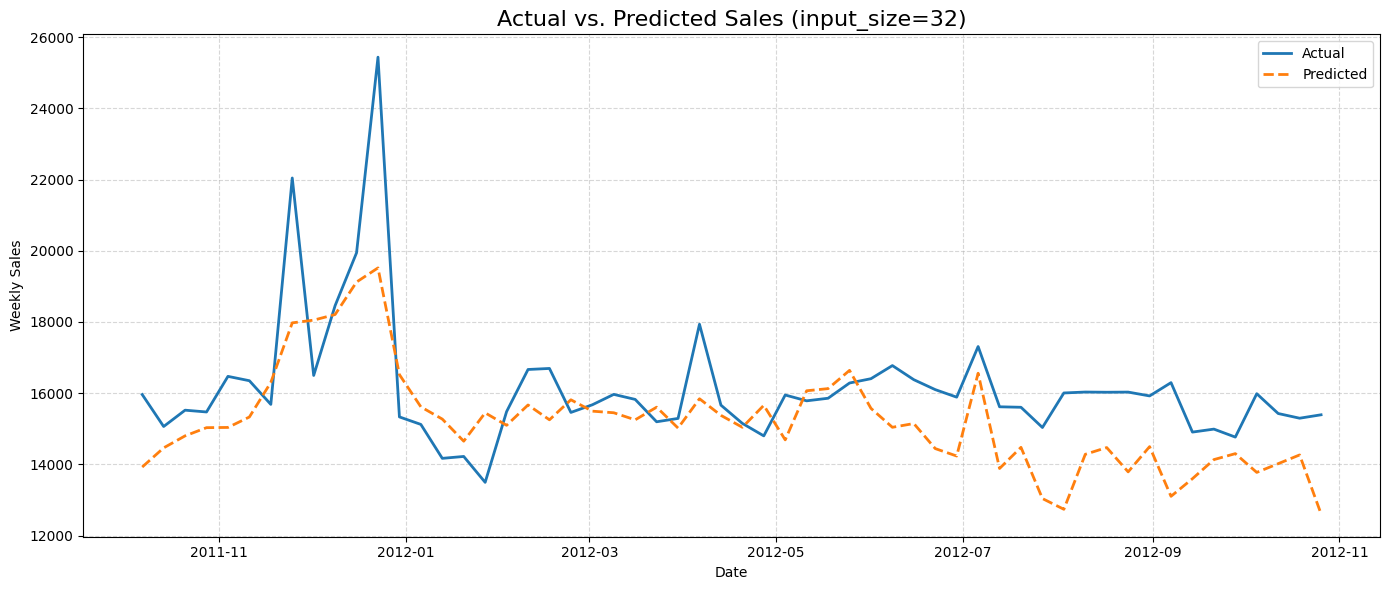

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 64


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2753.33
RMSE: 6053.84


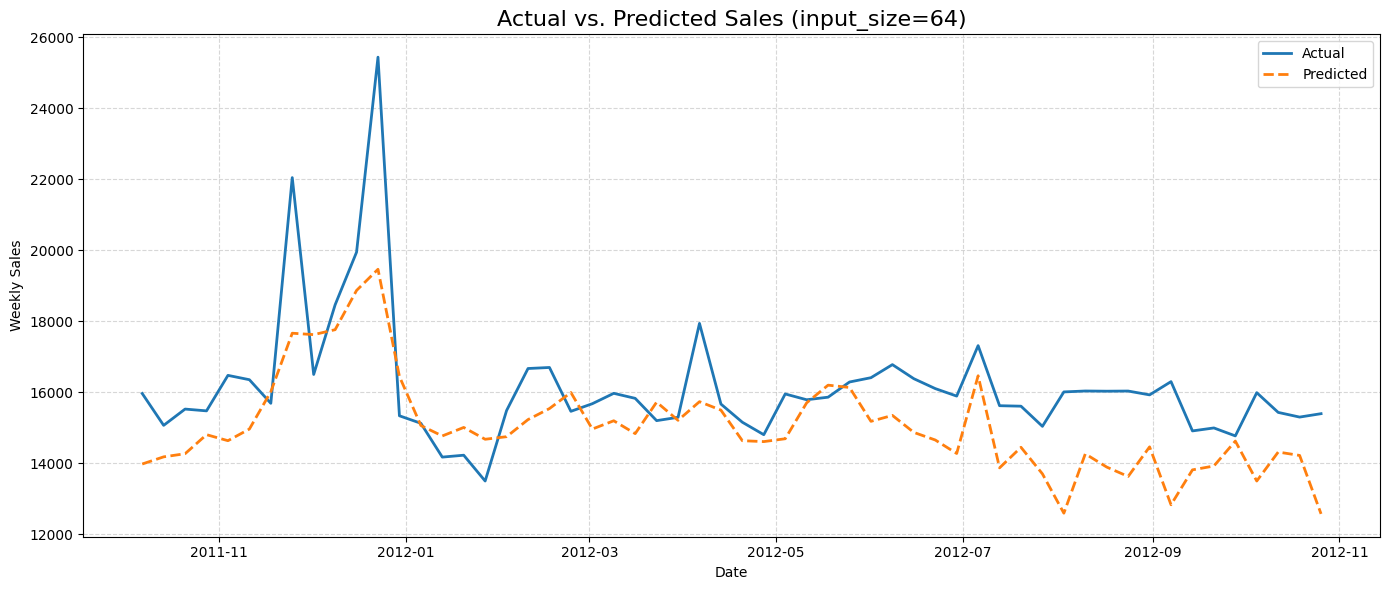

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 128


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2735.81
RMSE: 6019.49


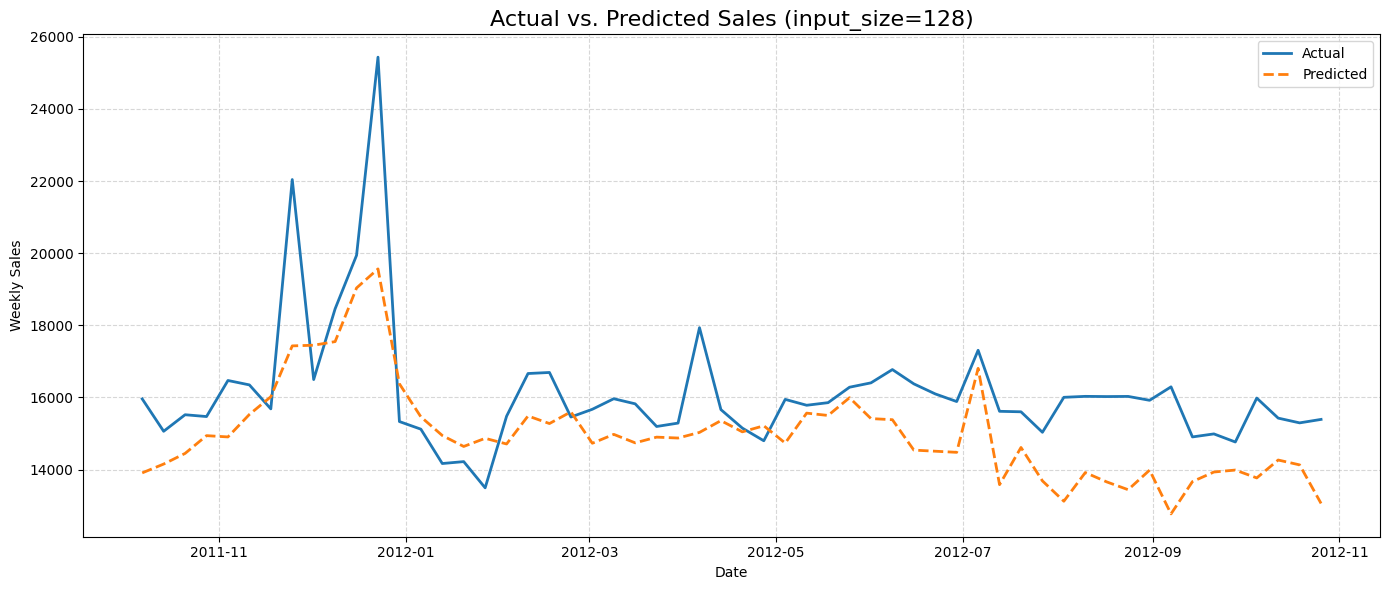

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 256


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2723.77
RMSE: 6010.43


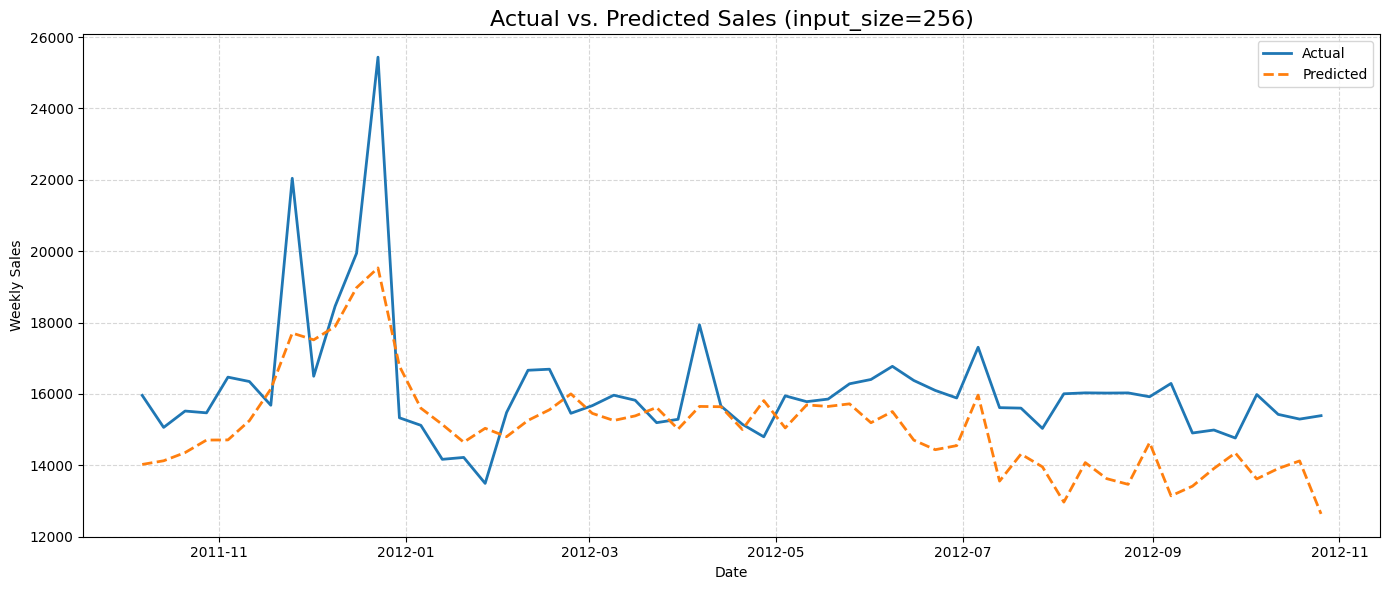


Best input_size: 32 with WMAE: 2718.80


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def compute_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

best_wmae = float('inf')
best_param = None

for param in [32, 64, 128, 256]:
    print(f"\nTraining with input_size = {param}")

    model = PatchTST(
        h=60,
        input_size=52,
        patch_len=8,
        batch_size=param,
        stride=4,
        n_heads=4,
        dropout=0.1,
        max_steps=100,
        learning_rate=5e-4,
        enable_progress_bar=True
    )

    patch_model = NeuralForecastWrapper(model=model)
    patch_model.fit(X_train, y_train)

    y_pred = patch_model.predict(X_valid)

    wmae = compute_wmae(y_valid.values, y_pred.values, X_valid['IsHoliday'].values)
    rmse = np.sqrt(mean_squared_error(y_valid.values, y_pred.values))

    print(f"WMAE: {wmae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    if wmae < best_wmae:
        best_wmae = wmae
        best_param = param

    df_plot = pd.DataFrame({
        'Date': pd.to_datetime(X_valid['Date']),
        'Actual': y_valid.values,
        'Predicted': y_pred.values
    })

    df_plot_grouped = df_plot.groupby('Date')[['Actual', 'Predicted']].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_plot_grouped, x='Date', y='Actual', label='Actual', linewidth=2)
    sns.lineplot(data=df_plot_grouped, x='Date', y='Predicted', label='Predicted', linewidth=2, linestyle='--')

    plt.title(f'Actual vs. Predicted Sales (input_size={param})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print(f"\nBest input_size: {best_param} with WMAE: {best_wmae:.2f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.0001


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2919.17
RMSE: 6562.96


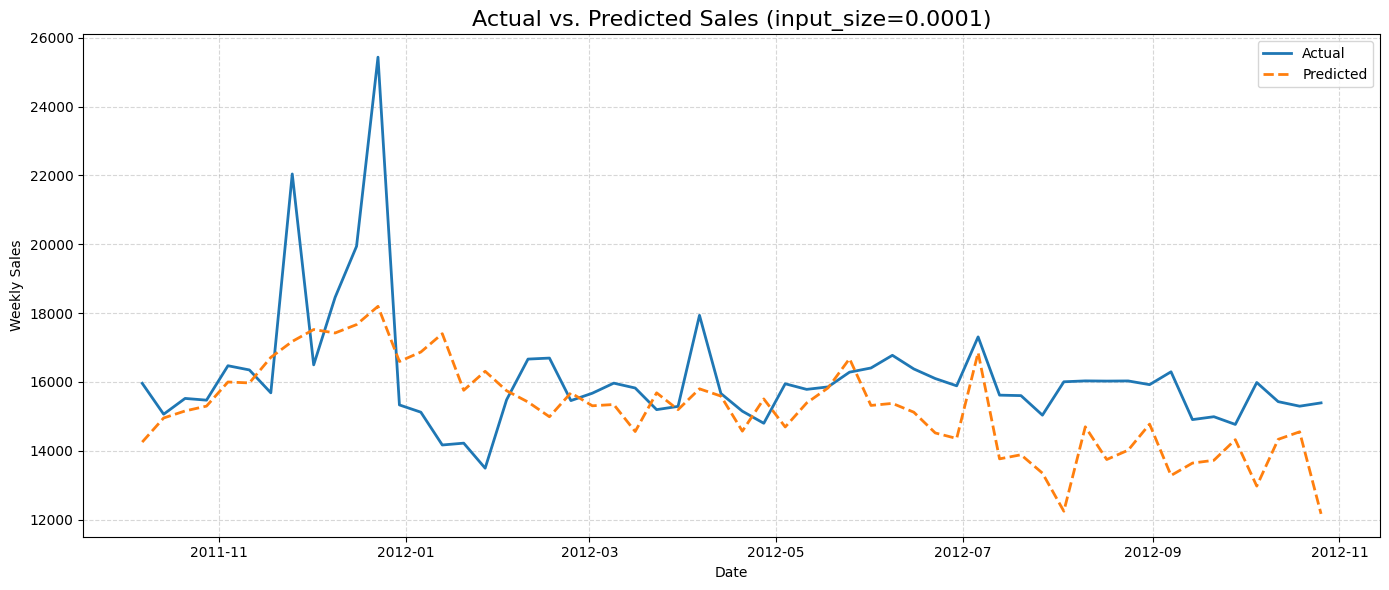

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.0005


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2718.80
RMSE: 6022.13


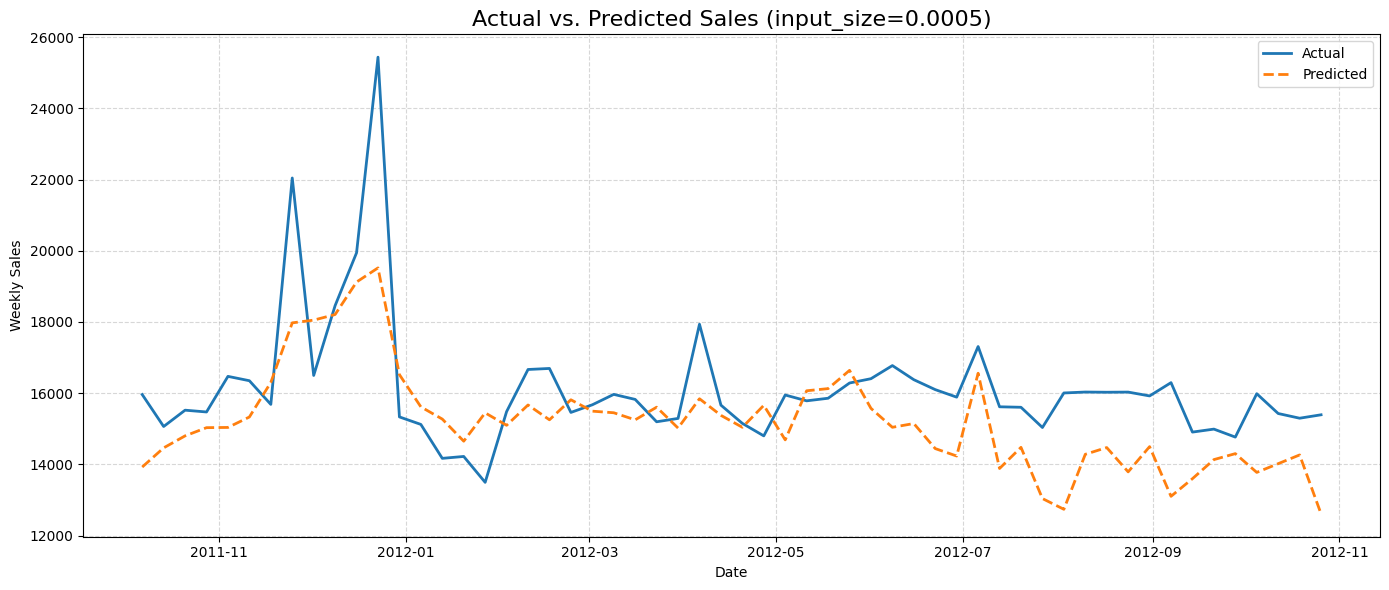

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.001


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2622.47
RMSE: 5999.14


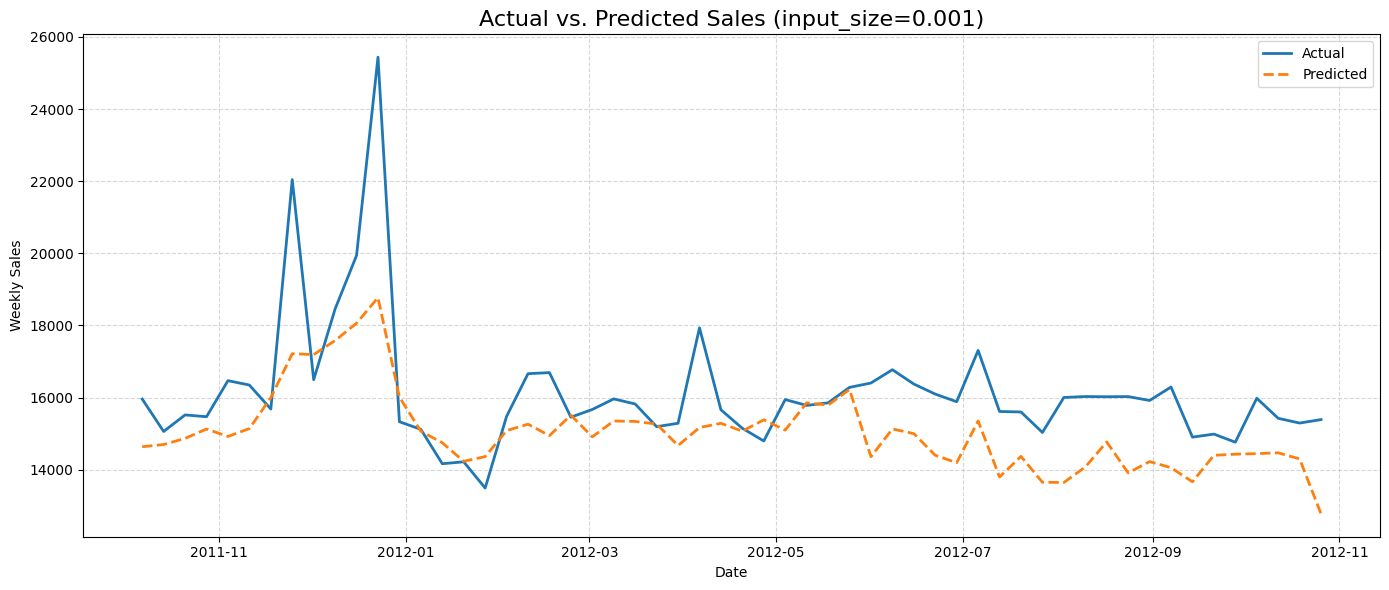

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.005


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 3050.39
RMSE: 7280.69


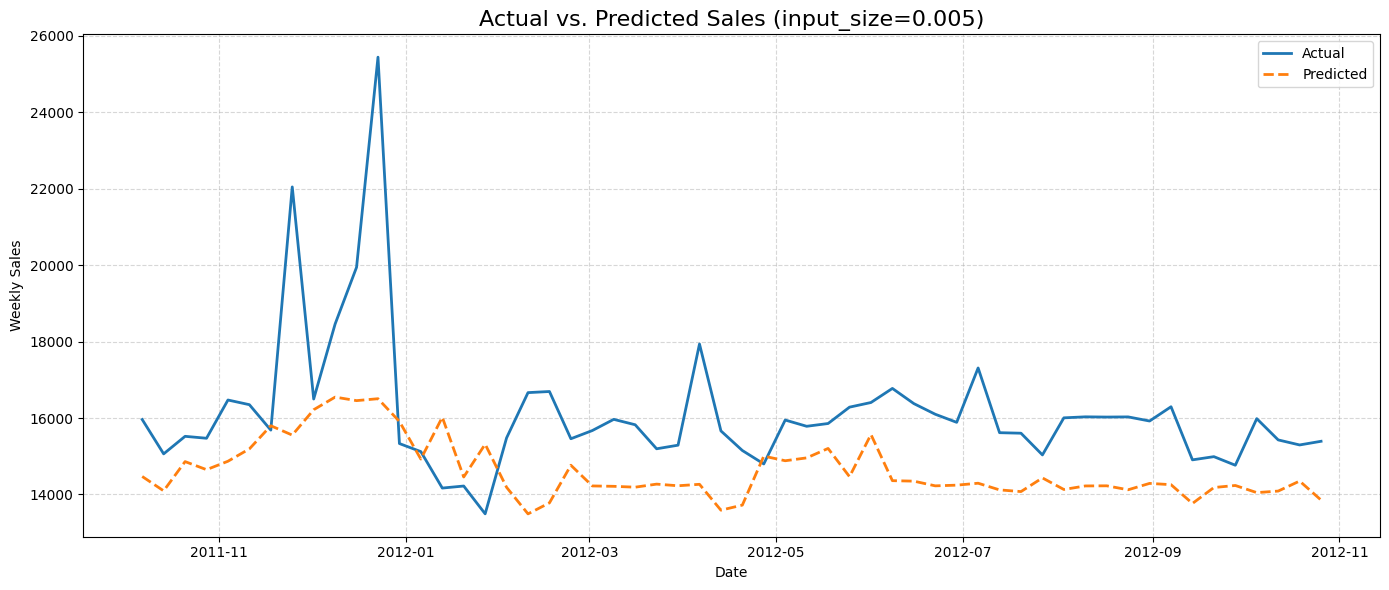


Best input_size: 0.001 with WMAE: 2622.47


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def compute_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

best_wmae = float('inf')
best_param = None

for param in [1e-4, 5e-4, 1e-3, 5e-3]:
    print(f"\nTraining with input_size = {param}")

    model = PatchTST(
        h=60,
        input_size=52,
        patch_len=8,
        batch_size=32,
        stride=4,
        n_heads=4,
        dropout=0.1,
        max_steps=100,
        learning_rate=param,
        enable_progress_bar=True
    )

    patch_model = NeuralForecastWrapper(model=model)
    patch_model.fit(X_train, y_train)

    y_pred = patch_model.predict(X_valid)

    wmae = compute_wmae(y_valid.values, y_pred.values, X_valid['IsHoliday'].values)
    rmse = np.sqrt(mean_squared_error(y_valid.values, y_pred.values))

    print(f"WMAE: {wmae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    if wmae < best_wmae:
        best_wmae = wmae
        best_param = param

    df_plot = pd.DataFrame({
        'Date': pd.to_datetime(X_valid['Date']),
        'Actual': y_valid.values,
        'Predicted': y_pred.values
    })

    df_plot_grouped = df_plot.groupby('Date')[['Actual', 'Predicted']].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_plot_grouped, x='Date', y='Actual', label='Actual', linewidth=2)
    sns.lineplot(data=df_plot_grouped, x='Date', y='Predicted', label='Predicted', linewidth=2, linestyle='--')

    plt.title(f'Actual vs. Predicted Sales (input_size={param})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print(f"\nBest input_size: {best_param} with WMAE: {best_wmae:.2f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.0


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2623.39
RMSE: 5957.68


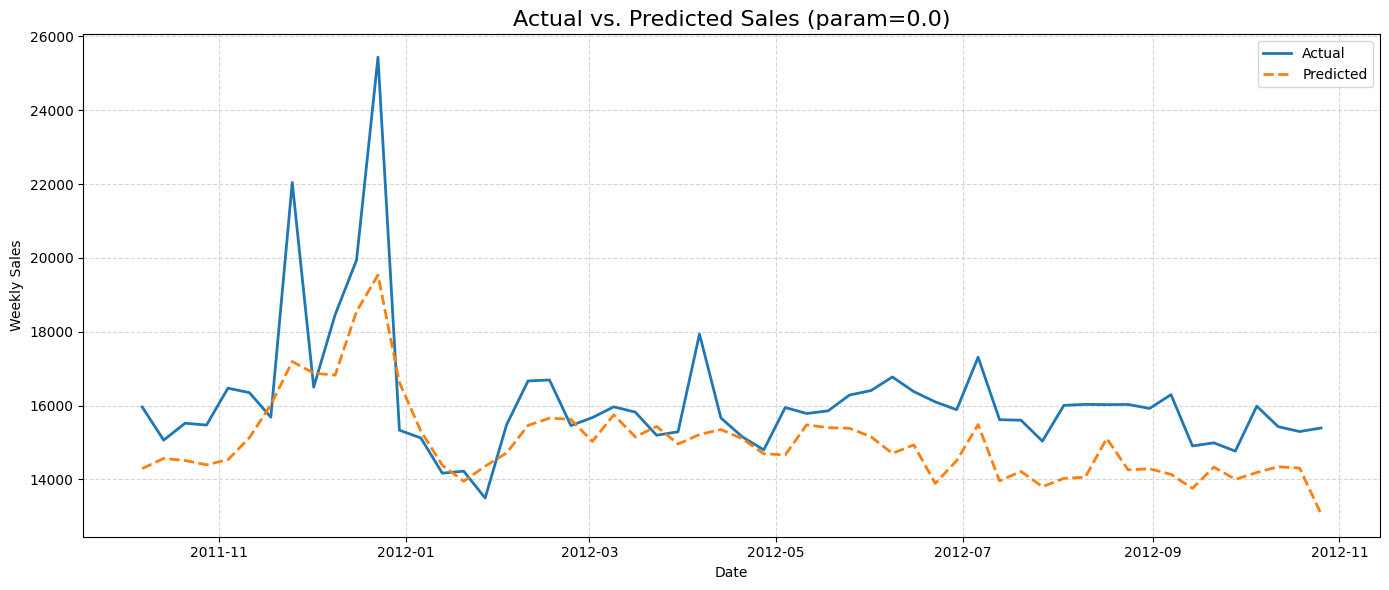

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.1


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2622.47
RMSE: 5999.14


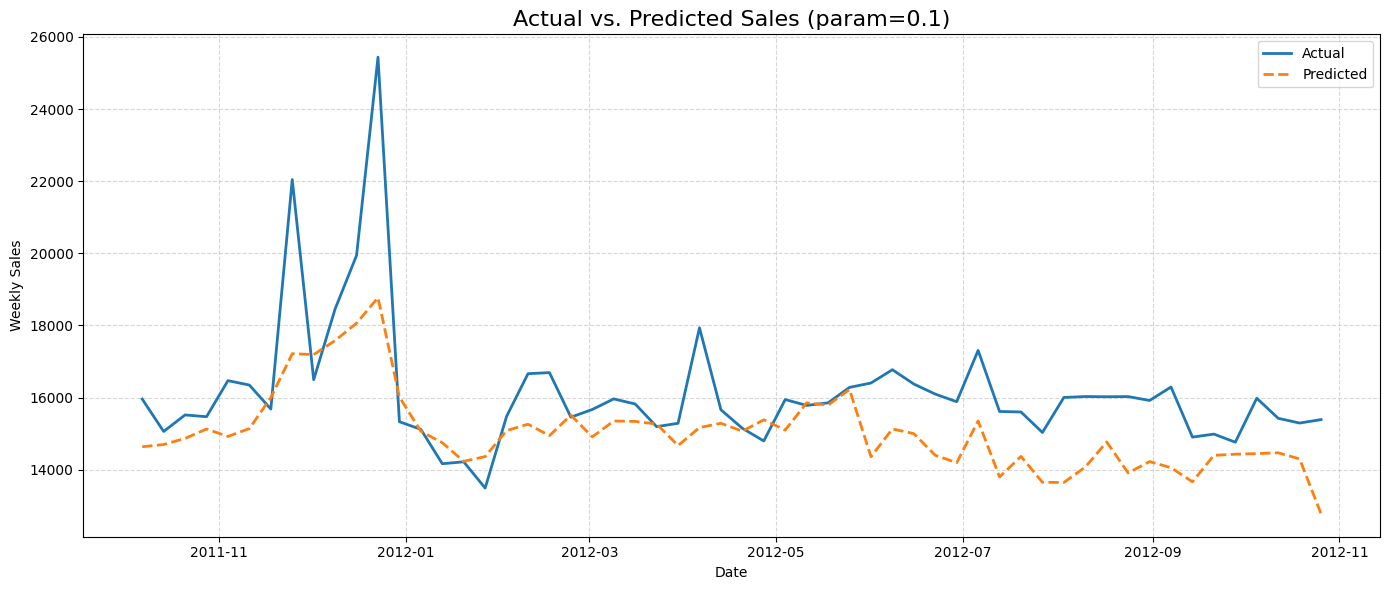

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.2


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2643.88
RMSE: 6015.54


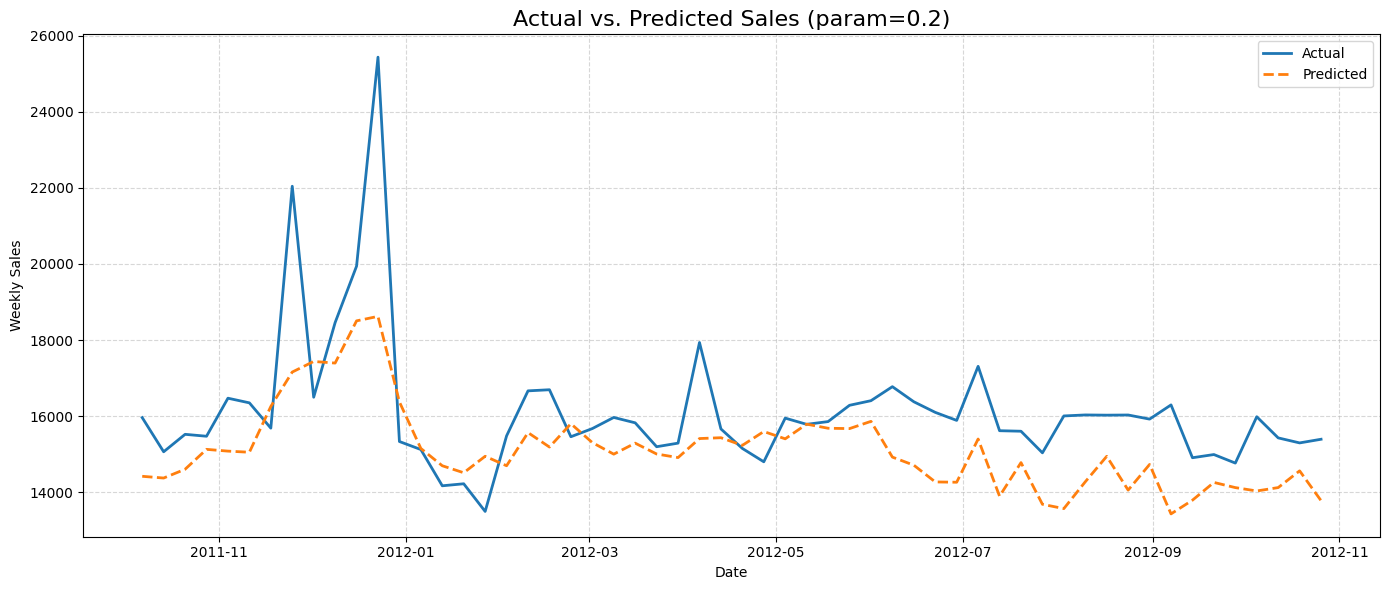

INFO:lightning_fabric.utilities.seed:Seed set to 1



Training with input_size = 0.3


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 500 K  | train
-----------------------------------------------------------
500 K     Trainable params
3         Non-trainable params
500 K     Total params
2.001     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

WMAE: 2670.48
RMSE: 6046.41


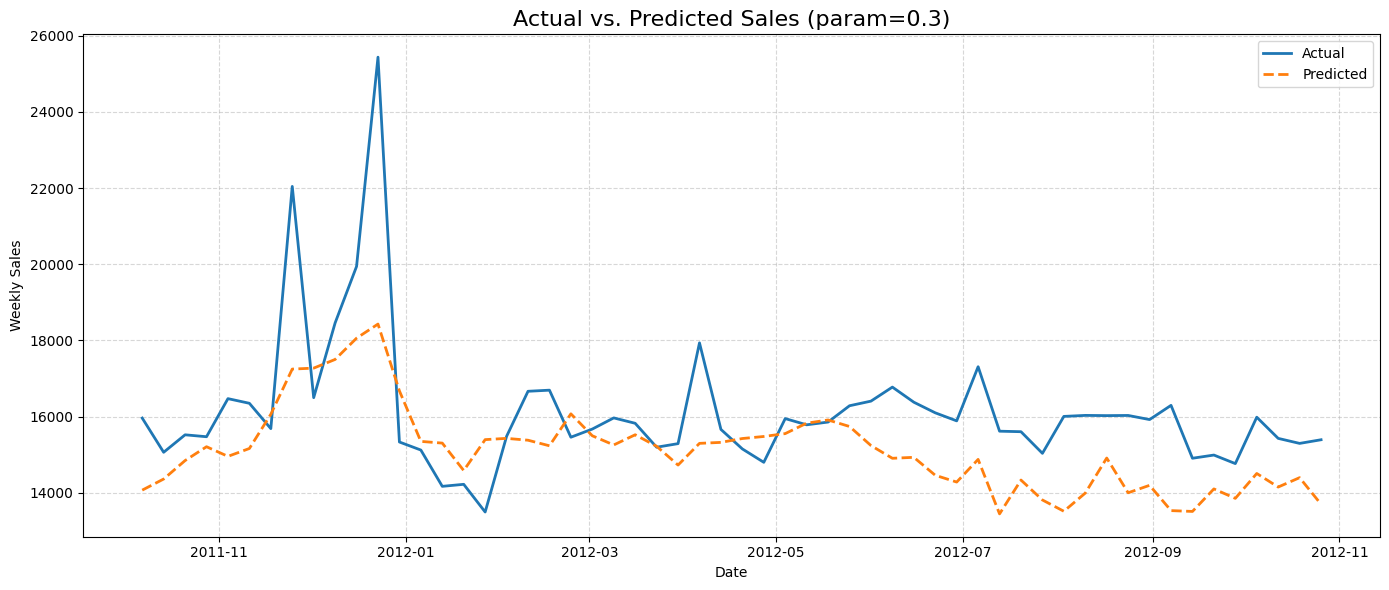


Best param: 0.1 with WMAE: 2622.47


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def compute_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

best_wmae = float('inf')
best_param = None

for param in [0.0, 0.1, 0.2, 0.3]:
    print(f"\nTraining with input_size = {param}")

    model = PatchTST(
        h=60,
        input_size=52,
        patch_len=8,
        batch_size=32,
        stride=4,
        n_heads=4,
        dropout=param,
        max_steps=100,
        learning_rate=0.001,
        enable_progress_bar=True
    )

    patch_model = NeuralForecastWrapper(model=model)
    patch_model.fit(X_train, y_train)

    y_pred = patch_model.predict(X_valid)

    wmae = compute_wmae(y_valid.values, y_pred.values, X_valid['IsHoliday'].values)
    rmse = np.sqrt(mean_squared_error(y_valid.values, y_pred.values))

    print(f"WMAE: {wmae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    if wmae < best_wmae:
        best_wmae = wmae
        best_param = param

    df_plot = pd.DataFrame({
        'Date': pd.to_datetime(X_valid['Date']),
        'Actual': y_valid.values,
        'Predicted': y_pred.values
    })

    df_plot_grouped = df_plot.groupby('Date')[['Actual', 'Predicted']].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_plot_grouped, x='Date', y='Actual', label='Actual', linewidth=2)
    sns.lineplot(data=df_plot_grouped, x='Date', y='Predicted', label='Predicted', linewidth=2, linestyle='--')

    plt.title(f'Actual vs. Predicted Sales (param={param})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print(f"\nBest param: {best_param} with WMAE: {best_wmae:.2f}")
